# Notebook 03: Time Series Analysis & Seasonal Decomposition

## Project: Indian Air Quality Index (AQI) Comprehensive Analysis
## BTech Final Year Project - Data Science & Machine Learning (8th Semester)

### Objective:
Perform time series analysis including trend extraction, seasonal decomposition, stationarity tests, autocorrelation analysis, and forecasting.

### Prerequisites:
- Complete Notebook 01 (generates city_day_cleaned.csv)
- Libraries: pandas, numpy, matplotlib, seaborn, statsmodels

### Run Time: 15-20 minutes

## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
print('Libraries imported!')

Libraries imported!


### Explanation:

- **from statsmodels.tsa.seasonal import seasonal_decompose**: Decomposes time series into trend, seasonal, and residual components.

- **from statsmodels.tsa.stattools import adfuller**: Augmented Dickey-Fuller test for checking time series stationarity.

- **from statsmodels.tsa.stattools import acf**: Calculates autocorrelation function.

- **from statsmodels.tsa.stattools import pacf**: Calculates partial autocorrelation function.

- **from statsmodels.graphics.tsaplots import plot_acf**: Plots autocorrelation function visually.

- **from statsmodels.graphics.tsaplots import plot_pacf**: Plots partial autocorrelation function visually.

In [2]:
data_path = os.path.join('..', 'datasets', 'city_day_cleaned.csv')
df = pd.read_csv(data_path, parse_dates=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
print(f'Loaded {df.shape[0]} records from {df["Datetime"].min()} to {df["Datetime"].max()}')

Loaded 442985 records from 2015-01-01 00:00:00 to 2025-07-31 00:00:00


## Step 2: Create Daily AQI Time Series

In [3]:
daily_aqi = df.groupby('Datetime')['AQI'].mean().resample('D').mean()
daily_aqi = daily_aqi.interpolate(method='linear')
print(f'Daily time series: {len(daily_aqi)} days')
print(f'Missing values filled by interpolation: {daily_aqi.isna().sum()}')

Daily time series: 3865 days
Missing values filled by interpolation: 0


### Explanation:

- **.resample('D')**: Resamples data to daily frequency ('D' = daily).

- **.interpolate(method='linear')**: Fills missing values using linear interpolation (draws straight line between known points).

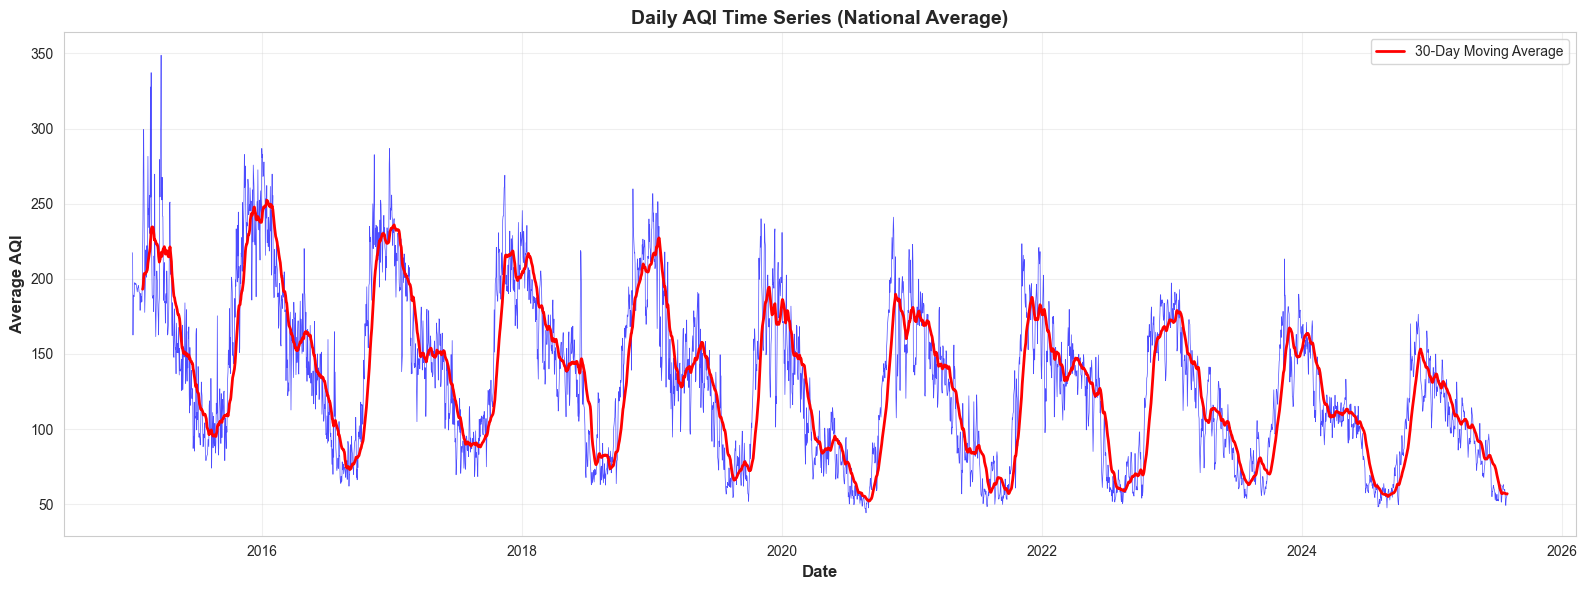

In [4]:
plt.figure(figsize=(16, 6))
plt.plot(daily_aqi.index, daily_aqi.values, linewidth=0.5, alpha=0.7, color='blue')
rolling_mean = daily_aqi.rolling(window=30).mean()
plt.plot(rolling_mean.index, rolling_mean.values, linewidth=2, color='red', label='30-Day Moving Average')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Average AQI', fontsize=12, fontweight='bold')
plt.title('Daily AQI Time Series (National Average)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Explanation:

- **.rolling(window=30).mean()**: Calculates rolling mean over 30-day window (smooths out short-term fluctuations).

## Step 3: Seasonal Decomposition

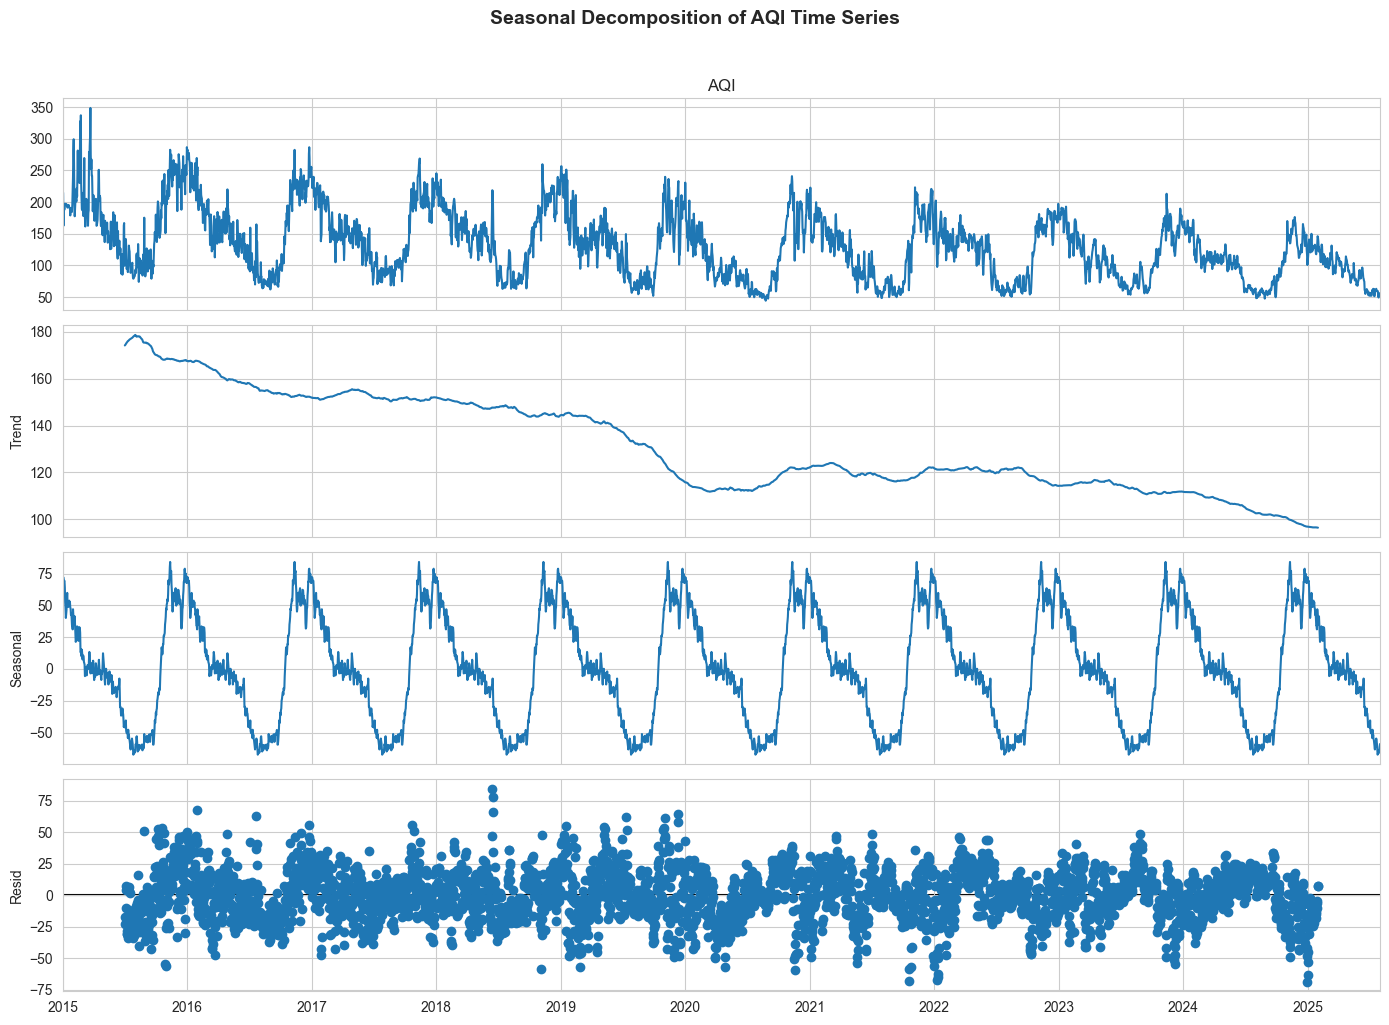

In [5]:
decomposition = seasonal_decompose(daily_aqi.dropna(), model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Seasonal Decomposition of AQI Time Series', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Explanation:

- **seasonal_decompose()**: Decomposes time series into three components: Trend, Seasonal, and Residual.

- **model='additive'**: Assumes seasonal variation is constant over time (Observed = Trend + Seasonal + Residual).

- **period=365**: Sets seasonal period to 365 days (yearly cycle).

- **Trend**: Long-term direction of the data (upward/downward).

- **Seasonal**: Repeating patterns within fixed periods (yearly cycles).

- **Residual**: Random noise after removing trend and seasonal components.

## Step 4: Extract Trend Component

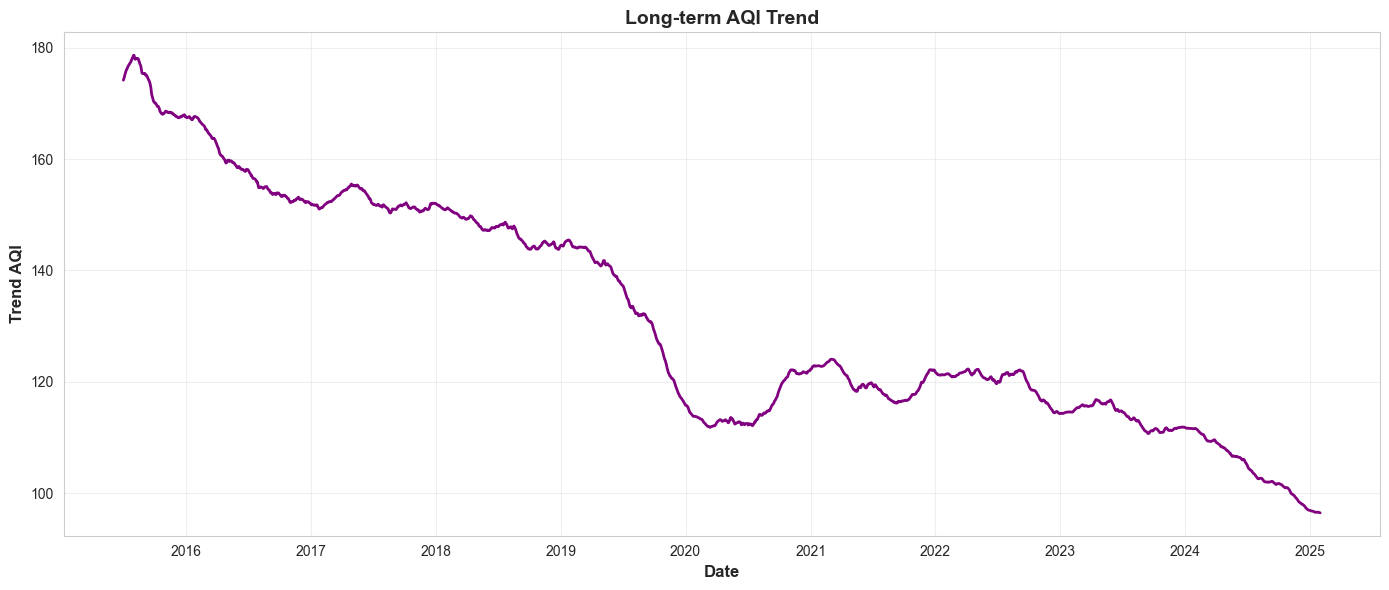

In [6]:
trend = decomposition.trend
plt.figure(figsize=(14, 6))
plt.plot(trend.index, trend.values, linewidth=2, color='purple')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Trend AQI', fontsize=12, fontweight='bold')
plt.title('Long-term AQI Trend', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5: Extract Seasonal Component

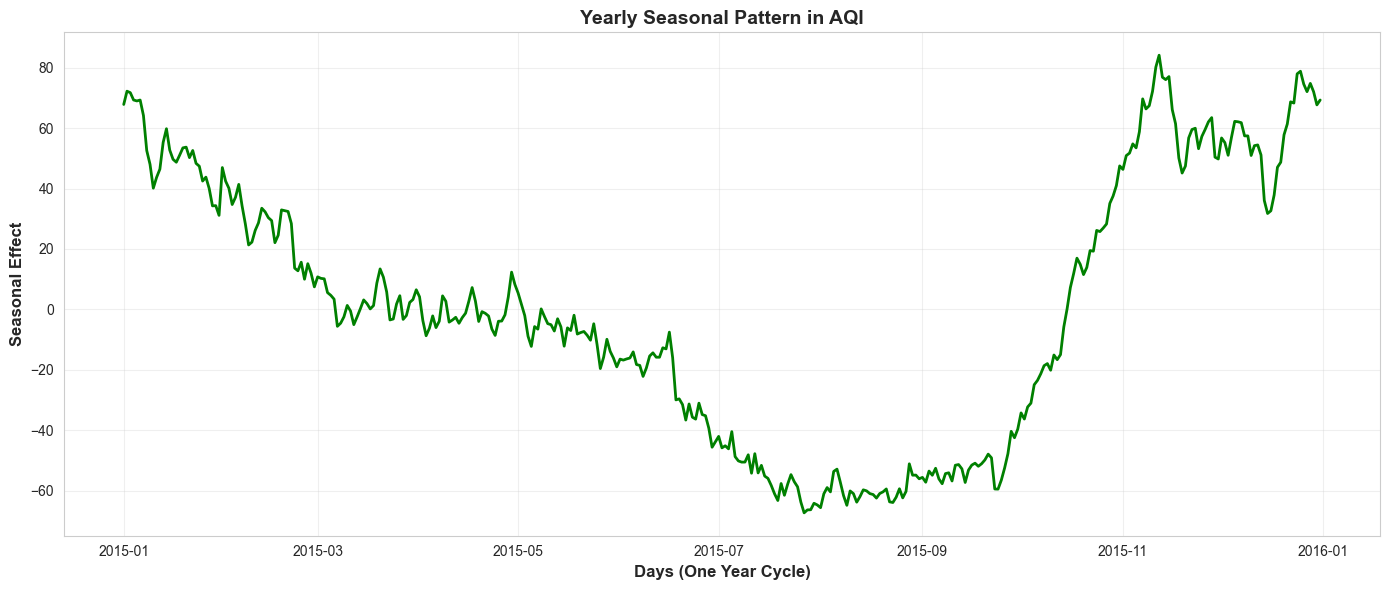

In [7]:
seasonal = decomposition.seasonal
plt.figure(figsize=(14, 6))
plt.plot(seasonal.index[:365], seasonal.values[:365], linewidth=2, color='green')
plt.xlabel('Days (One Year Cycle)', fontsize=12, fontweight='bold')
plt.ylabel('Seasonal Effect', fontsize=12, fontweight='bold')
plt.title('Yearly Seasonal Pattern in AQI', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Stationarity Test - Augmented Dickey-Fuller

In [8]:
adf_result = adfuller(daily_aqi.dropna())
print('Augmented Dickey-Fuller Test Results:')
print(f'Test Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.6f}')
print(f'Critical Values:')
for key, value in adf_result[4].items():
    print(f'  {key}: {value:.4f}')
print(f'\nResult: {"STATIONARY" if adf_result[1] < 0.05 else "NON-STATIONARY"}')

Augmented Dickey-Fuller Test Results:
Test Statistic: -4.3005
p-value: 0.000443
Critical Values:
  1%: -3.4321
  5%: -2.8623
  10%: -2.5672

Result: STATIONARY


### Explanation:

- **adfuller()**: Performs Augmented Dickey-Fuller test to check if time series is stationary.

- **Stationary**: Statistical properties (mean, variance) don't change over time.

- **p-value < 0.05**: Time series is stationary (has constant statistical properties).

- **p-value > 0.05**: Time series is non-stationary (has trend or seasonality).

- **Critical Values**: Thresholds for different confidence levels (1%, 5%, 10%).

## Step 7: Make Series Stationary (Differencing)

In [9]:
if adf_result[1] > 0.05:
    print('Making series stationary using first-order differencing...')
    differenced = daily_aqi.diff().dropna()
    adf_result_diff = adfuller(differenced)
    print(f'After differencing - Test Statistic: {adf_result_diff[0]:.4f}, p-value: {adf_result_diff[1]:.6f}')
    print(f'Result: {"STATIONARY" if adf_result_diff[1] < 0.05 else "NON-STATIONARY"}')
    plt.figure(figsize=(14, 6))
    plt.plot(differenced.index, differenced.values, linewidth=0.5, color='blue')
    plt.title('Differenced AQI Time Series (Stationary)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('Series is already stationary! No differencing needed.')

Series is already stationary! No differencing needed.


### Explanation:

- **.diff()**: Calculates difference between consecutive observations (removes trend).

- **First-order differencing**: Subtracting previous value from current value.

- **Stationary series**: Required for many time series forecasting models (ARIMA, etc.).

## Step 8: Autocorrelation Function (ACF)

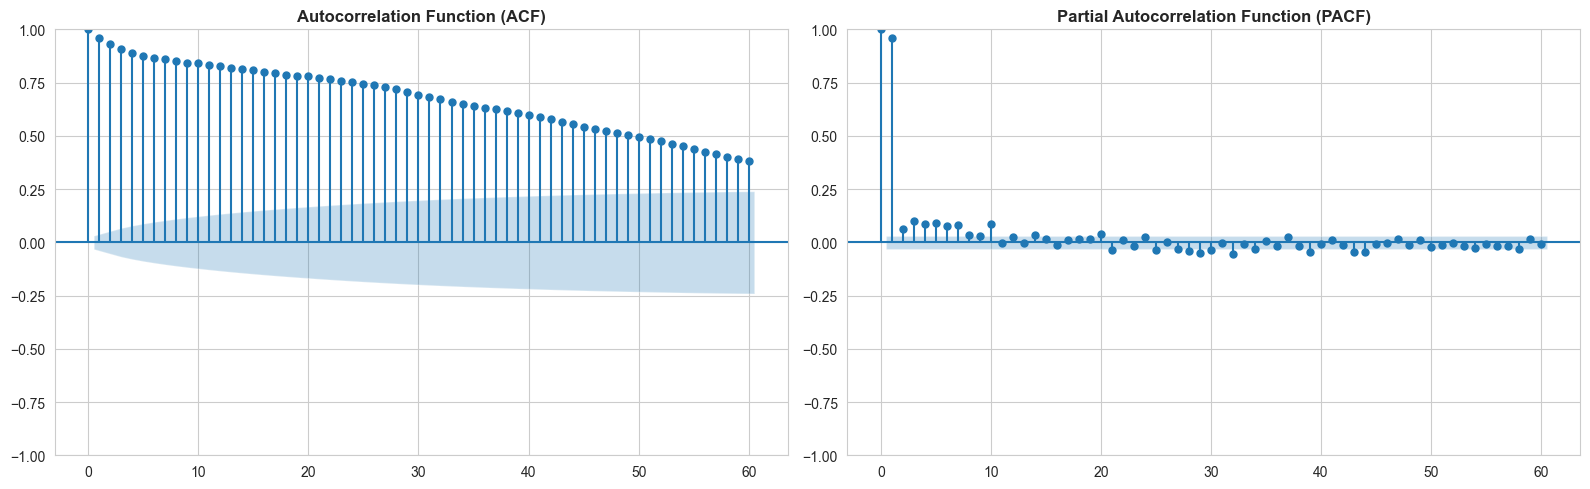

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(daily_aqi.dropna(), lags=60, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
plot_pacf(daily_aqi.dropna(), lags=60, ax=axes[1], method='yw')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Explanation:

- **plot_acf()**: Plots correlation of time series with its own lagged values.

- **lags=60**: Shows correlation up to 60 days back.

- **plot_pacf()**: Plots correlation after removing effects of intermediate lags.

- **method='yw'**: Uses Yule-Walker method for PACF calculation.

- **ACF**: Helps identify moving average (MA) order in ARIMA models.

- **PACF**: Helps identify autoregressive (AR) order in ARIMA models.

## Step 9: Monthly Time Series Heatmap

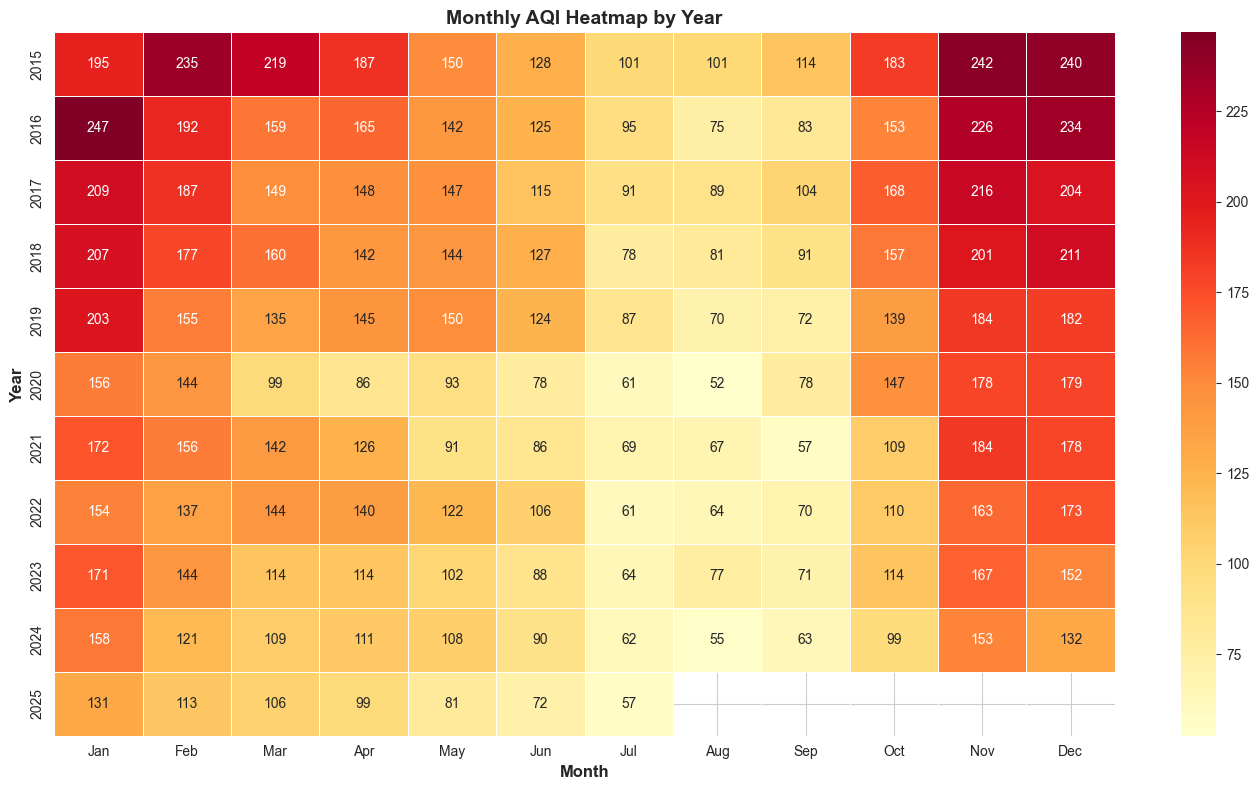

In [11]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
monthly_pivot = df.pivot_table(values='AQI', index='Year', columns='Month', aggfunc='mean')
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_pivot.columns = month_names
plt.figure(figsize=(14, 8))
sns.heatmap(monthly_pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Monthly AQI Heatmap by Year', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Year', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Explanation:

- **.pivot_table()**: Creates spreadsheet-style pivot table (rows=Year, columns=Month, values=mean AQI).

- **cmap='YlOrRd'**: Uses Yellow-Orange-Red colormap (darker = higher AQI).

- **annot=True**: Displays numerical values in each cell.

## Step 10: Rolling Statistics

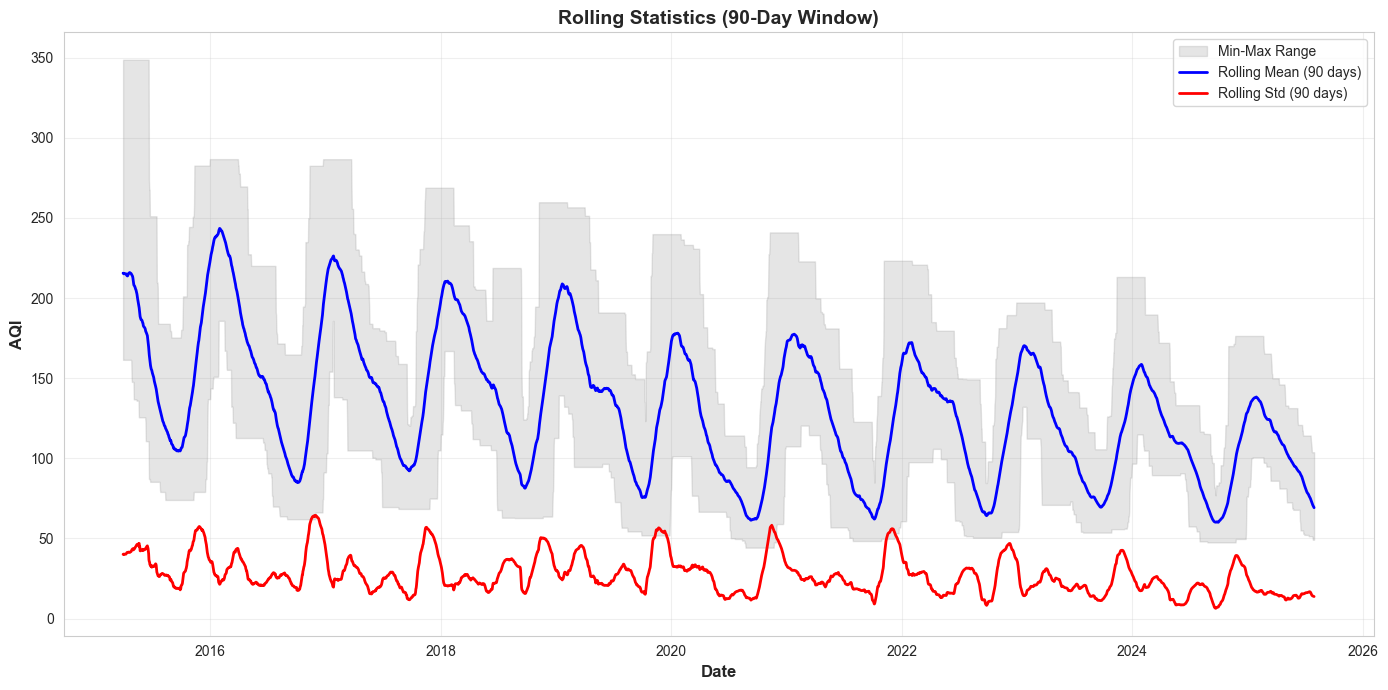

In [12]:
rolling_stats = pd.DataFrame({
    'Mean': daily_aqi.rolling(window=90).mean(),
    'Std': daily_aqi.rolling(window=90).std(),
    'Min': daily_aqi.rolling(window=90).min(),
    'Max': daily_aqi.rolling(window=90).max()
})
plt.figure(figsize=(14, 7))
plt.fill_between(rolling_stats.index, rolling_stats['Min'], rolling_stats['Max'], alpha=0.2, color='gray', label='Min-Max Range')
plt.plot(rolling_stats.index, rolling_stats['Mean'], linewidth=2, color='blue', label='Rolling Mean (90 days)')
plt.plot(rolling_stats.index, rolling_stats['Std'], linewidth=2, color='red', label='Rolling Std (90 days)')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('AQI', fontsize=12, fontweight='bold')
plt.title('Rolling Statistics (90-Day Window)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Explanation:

- **window=90**: Uses 90-day rolling window (quarterly statistics).

- **Rolling Mean**: Average over past 90 days (smooths volatility).

- **Rolling Std**: Standard deviation over past 90 days (measures volatility).

- **Min-Max Range**: Shows extreme values within the rolling window.

## Step 11: City-wise Time Series (Top 5)

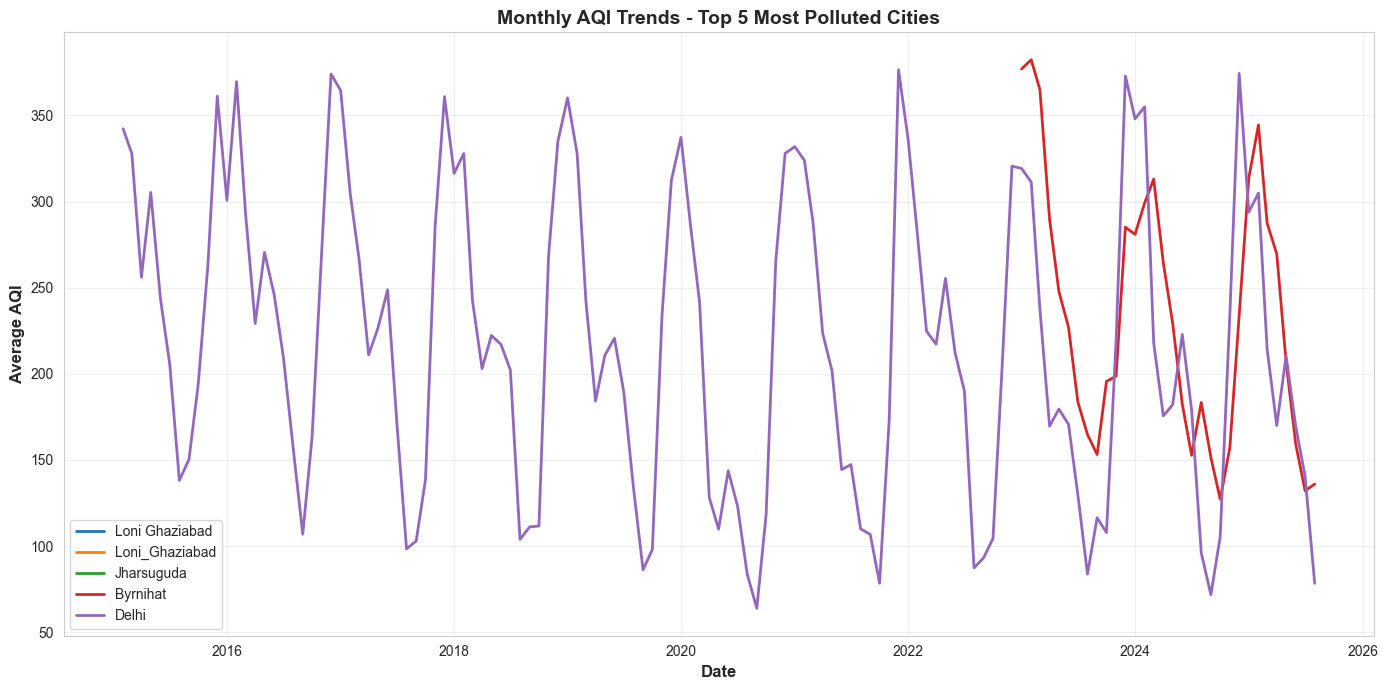

In [13]:
top_cities = df.groupby('City')['AQI'].mean().nlargest(5).index
city_ts = df[df['City'].isin(top_cities)].groupby(['City', 'Datetime'])['AQI'].mean().unstack(level=0)
city_ts = city_ts.resample('M').mean()
plt.figure(figsize=(14, 7))
for city in top_cities:
    plt.plot(city_ts.index, city_ts[city], linewidth=2, label=city)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Average AQI', fontsize=12, fontweight='bold')
plt.title('Monthly AQI Trends - Top 5 Most Polluted Cities', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Explanation:

- **nlargest(5)**: Gets top 5 cities with highest average AQI.

- **.unstack(level=0)**: Pivots City index level to columns (each city becomes a column).

- **resample('M')**: Resamples to monthly frequency ('M' = monthly).

## Step 12: Save Time Series Results

In [14]:
daily_aqi.to_csv(os.path.join('..', 'outputs', 'daily_aqi_series.csv'))
monthly_pivot.to_csv(os.path.join('..', 'outputs', 'monthly_aqi_heatmap.csv'))
rolling_stats.to_csv(os.path.join('..', 'outputs', 'rolling_statistics.csv'))
print('Time series results saved to outputs/ folder!')
print('READY FOR NOTEBOOK 04')

Time series results saved to outputs/ folder!
READY FOR NOTEBOOK 04


## Summary

Completed time series analysis:
1. Daily AQI time series with interpolation
2. 30-day rolling average smoothing
3. Seasonal decomposition (trend + seasonal + residual)
4. Augmented Dickey-Fuller stationarity test
5. First-order differencing for stationarity
6. ACF and PACF analysis
7. Monthly heatmap by year
8. Rolling statistics (mean, std, min, max)
9. Multi-city time series comparison

**Key Findings:**
- AQI shows strong yearly seasonality (winter peaks, monsoon lows)
- Series is non-stationary (has trend component)
- Significant autocorrelation at 365-day lag
- Top polluted cities show similar seasonal patterns

**Next**: Notebook 04 - Feature Engineering & Data Preprocessing for ML